In [4]:
import os
import re
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [5]:
input_dir = '../dataset/dataset_final/results_timing_analyzed'

df_dict = {}

for df_name in os.listdir(input_dir):
    if 'Aria' not in df_name:
        model = re.sub('_analyzed.parquet','',df_name)
        df_dict[model] = pl.read_parquet(f'{input_dir}/{df_name}')

/tmp/ipykernel_16646/59184737.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(inference_times, labels=model_names, patch_artist=True)


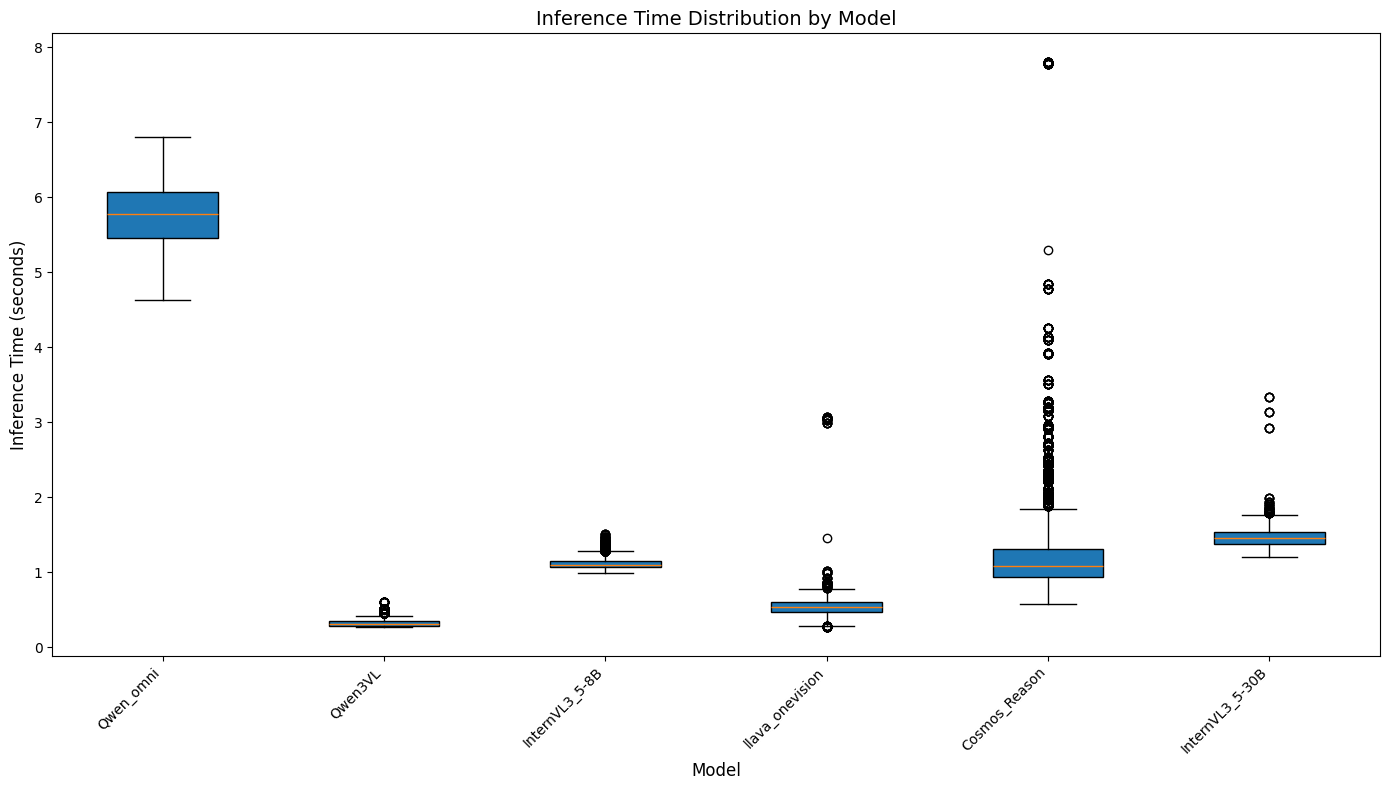

In [6]:
# Create a box plot of inference time for all dataframes
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for boxplot
inference_times = []
model_names = []

for model_name, df in df_dict.items():
    if 'inference_time' in df.columns:
        inference_times.append(df['inference_time'].to_numpy())
        model_names.append(model_name)

# Create boxplot
bp = ax.boxplot(inference_times, labels=model_names, patch_artist=True)

# Customize the plot
ax.set_ylabel('Inference Time (seconds)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Inference Time Distribution by Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
#plt.savefig('../report/figures/inference_time_boxplot.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_16646/3766704042.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(inference_times, labels=model_names, patch_artist=True)


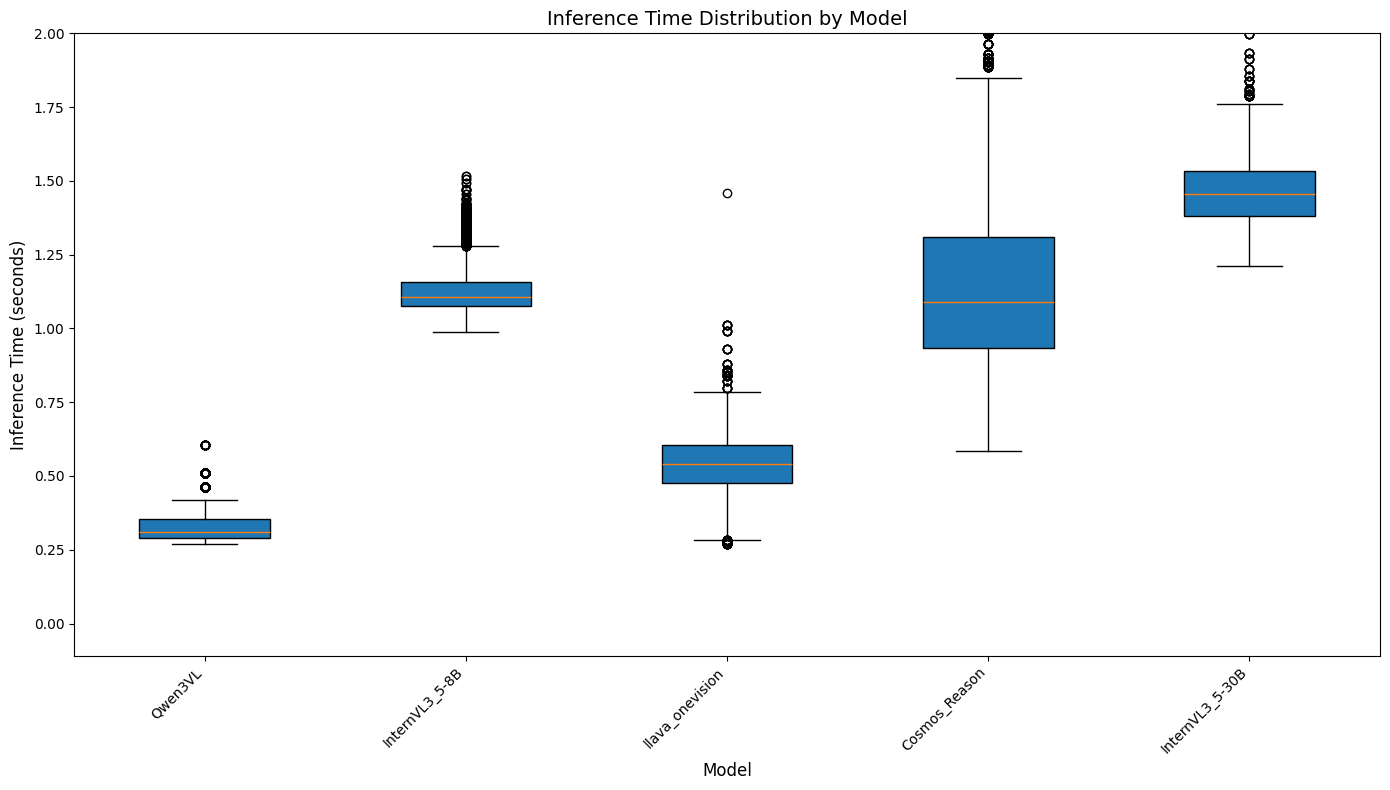

In [9]:
# Create a box plot of inference time for all dataframes
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for boxplot
inference_times = []
model_names = []

for model_name, df in df_dict.items():
    if 'Qwen_omni' not in model_name:
        if 'inference_time' in df.columns:
            inference_times.append(df['inference_time'].to_numpy())
            model_names.append(model_name)

# Create boxplot
bp = ax.boxplot(inference_times, labels=model_names, patch_artist=True)

# Customize the plot
ax.set_ylabel('Inference Time (seconds)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Inference Time Distribution by Model', fontsize=14)
ax.set_ylim(top=2.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
#plt.savefig('../report/figures/inference_time_boxplot.pdf', bbox_inches='tight')
plt.show()